In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

C:\Users\Josh\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the 2026 dataset: https://memory.psych.upenn.edu/Data_Archive#2026

In [14]:
# Get data
data = pd.read_csv('data/Exp3_AllData.csv', header=0, sep=',')
data.head()
data = data[~np.isnan(data["Output_Rank"])]

# Convert to ints
data["Listnum"] = data["Listnum"].astype(int)
data["Spatial_Input_Order"] = data["Spatial_Input_Order"].astype(int)
data["Temporal_Input_Position"] = data["Temporal_Input_Position"].astype(int)
data["Length"] = data["Length"].astype(int)
data["Serial_Pos_Encoded"] = data["Serial_Pos_Encoded"].astype(int)
data["Output_Rank"] = data["Output_Rank"].astype(int)

# Filter only for varied data
data = data[data["List_Type"] == 'Varied']

# Filter separately for the spatial and temporal conditions
spatial_data = data[data["Order_Type"] == 'Spatial']
temporal_data = data[data["Order_Type"] == 'Temporal']

# Only use a fraction of the data
train_percent = 1.00
spatial_data = spatial_data.sample(n=int(spatial_data.shape[0]*train_percent))
temporal_data = temporal_data.sample(n=int(temporal_data.shape[0]*train_percent))

spatial_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Spatial_Input_Order.values,
    "other_input_order": data.Temporal_Input_Position.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

temporal_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Temporal_Input_Position.values,
    "other_input_order": data.Spatial_Input_Order.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

First, we will create a model for the spatial condition trials.

In [25]:
# Compile spatial model
spatial_model = CmdStanModel(stan_file="stan/varied_model.stan")

07:43:06 - cmdstanpy - INFO - compiling stan file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.stan to exe file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe
07:43:22 - cmdstanpy - INFO - compiled model executable: C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe


In [26]:
# Sample spatial model
spatial_fit = spatial_model.sample(data=spatial_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(spatial_fit.diagnose())

07:43:23 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   0%|          | 1/3500 [00:00<23:24,  2.49it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:03<02:04, 27.36it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:06<01:50, 29.86it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:09<01:37, 32.98it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:12<01:28, 35.20it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:14<01:24, 35.68it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:17<01:21, 35.75it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:19<01:12, 38.38it/s, (Warmup)]

chain 1:  26%|██▌       | 900/3500 [00:23<00:59, 43.69it/s, (Warmup)]




chain 1:  29%|██▊       | 1000/3500 [00:26<01:03, 39.33it/s, (Warmup)]

chain 1:  29%|██▊       | 1000/3500 [00:26<01:03, 39.33it/s, (Sampling)]

chain 1:  31%|███▏      | 1100/3500 [00:31<01:15, 31.81it/s, (Sampling)]


chain 1:  34


07:45:21 - cmdstanpy - INFO - CmdStan done processing.
07:45:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'varied_model.stan', line 30, column 8 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'varied_model.stan', line 30, column 8 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'varied_model.stan', line 30, column 8 to column 65)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [27]:
spatial_fit_data = az.from_cmdstanpy(spatial_fit)
spatial_summary = az.summary(data=spatial_fit_data, var_names=["sigma_base_recall", "beta_other_order"], round_to="none")

# Display sampling data
display(spatial_summary)

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in spatial_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = spatial_fit.draws_pd()
display(draws_df.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_base_recall,3.262420,0.288865,2.707228,3.800643,0.001865,0.003380,23771.681373,7135.034345,0.999971
beta_other_order[0],0.520332,0.295117,-0.055350,1.063658,0.001880,0.003407,24450.669975,7481.498596,0.999990
beta_other_order[1],0.221671,0.293134,-0.343336,0.762040,0.001918,0.003399,23198.457815,7027.881187,1.000059
beta_other_order[2],0.188365,0.294228,-0.367011,0.737805,0.001882,0.003402,24117.527459,7086.076347,1.000038
beta_other_order[3],0.011163,0.292954,-0.560331,0.547142,0.001899,0.003328,23590.340044,7017.171544,1.000080
beta_other_order[4],-0.219234,0.292839,-0.789032,0.317748,0.001874,0.003427,24270.558228,6928.984285,1.000095
beta_other_order[5],-0.509970,0.290956,-1.062843,0.034524,0.001882,0.003369,23805.316628,7010.132379,1.000057
beta_other_order[6],-0.381639,0.292926,-0.929770,0.177970,0.001911,0.003401,23345.524202,7372.694864,0.999965
beta_other_order[7],-0.419068,0.291325,-0.961795,0.141513,0.001880,0.003351,23851.192602,7385.998377,1.000046
beta_other_order[8],-0.106676,0.293446,-0.656615,0.456069,0.001891,0.003428,23770.847873,6999.469670,0.999930


Number of 13 R_hat Values Past Threshold: 0
Average R_hat Value: 1.0000233689229683
R_hat score: 99.76631077031728


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,recall_order_gen[19430],recall_order_gen[19431],recall_order_gen[19432],recall_order_gen[19433],recall_order_gen[19434],recall_order_gen[19435],recall_order_gen[19436],recall_order_gen[19437],recall_order_gen[19438],recall_order_gen[19439]
0,1.0,1.0,1.0,-33087.182,1.000000,0.670511,3.0,7.0,0.0,33093.491,...,4.0,6.0,1.0,9.0,12.0,8.0,6.0,5.0,7.0,11.0
1,1.0,2.0,2.0,-33085.350,0.837398,0.670511,3.0,7.0,0.0,33095.727,...,7.0,9.0,1.0,6.0,7.0,6.0,3.0,6.0,1.0,5.0
2,1.0,3.0,3.0,-33085.822,0.904625,0.670511,3.0,7.0,0.0,33091.832,...,11.0,6.0,1.0,8.0,11.0,9.0,4.0,1.0,3.0,11.0
3,1.0,4.0,4.0,-33087.734,0.865170,0.670511,3.0,7.0,0.0,33093.944,...,7.0,5.0,3.0,8.0,11.0,12.0,7.0,4.0,5.0,2.0
4,1.0,5.0,5.0,-33085.125,0.941103,0.670511,3.0,7.0,0.0,33094.274,...,5.0,10.0,2.0,7.0,12.0,9.0,2.0,4.0,1.0,12.0


Total Data Accuracy: 0.4490971757806472
Total Model Accuracy: 0.1940664180256186


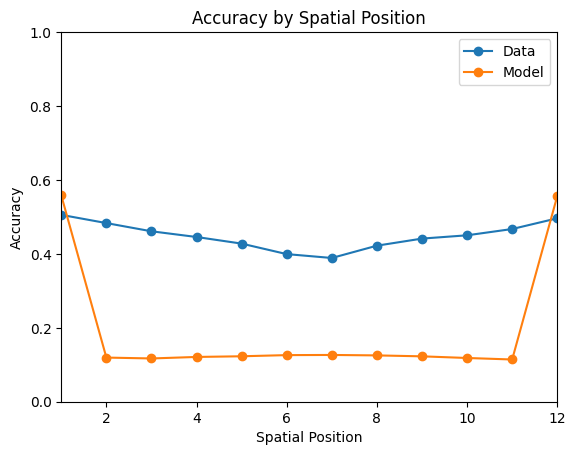

In [42]:
# Check that the spatial model has the same accuracy as the true results
spatial_main_input_order = spatial_data_dict["main_input_order"]
spatial_recall_order = spatial_data_dict["recall_order"]
spatial_recall_order_gen = spatial_fit.stan_variable("recall_order_gen")

data_correct_recall = (spatial_main_input_order == spatial_recall_order)
data_accuracy = np.mean(data_correct_recall)

model_correct_recall = (spatial_main_input_order == spatial_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (spatial_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (spatial_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Spatial Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Spatial Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()


Next, we will create a model for the temporal condition trials.

In [ ]:
# Compile temporal model
temporal_model = CmdStanModel(stan_file="stan/varied_model.stan")

In [ ]:
# Sample temporal model
temporal_fit = temporal_model.sample(data=temporal_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(temporal_fit.diagnose())

In [ ]:
temporal_fit_data = az.from_cmdstanpy(temporal_fit)
temporal_summary = az.summary(data=temporal_fit_data, var_names=["sigma_base_recall", "beta_other_order"], round_to="none")

# Display sampling data
display(temporal_summary)

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in temporal_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = temporal_fit.draws_pd()
display(draws_df.head())

In [ ]:
# Check that the temporal model has the same accuracy as the true results
temporal_main_input_order = temporal_data_dict["main_input_order"]
temporal_recall_order = temporal_data_dict["recall_order"]
temporal_recall_order_gen = temporal_fit.stan_variable("recall_order_gen")

data_correct_recall = (temporal_main_input_order == temporal_recall_order)
data_accuracy = np.mean(data_correct_recall)

model_correct_recall = (temporal_main_input_order == temporal_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (temporal_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (temporal_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Temporal Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Temporal Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()
